In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import keras
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.integrate import simpson

import sys
sys.path.append("..")
from LJEOS import calc_mu

# Enable or disable Tensor Float 32 Execution
tf.config.experimental.enable_tensor_float_32_execution(False)

2025-12-24 12:06:15.372485: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-24 12:06:15.467957: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766577975.506963    8060 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766577975.518141    8060 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-24 12:06:15.624742: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [3]:

def generate_windows(array, bins):
    """
    Generate sliding windows for the input array with a given bin size.

    Parameters:
    - array (np.ndarray): Input array.
    - bins (int): Number of bins on each side of the central bin.
    - mode (str): Padding mode for np.pad (default is "wrap").

    Returns:
    - np.ndarray: Array of sliding windows.
    """
    padded_array = np.pad(array, bins, mode="wrap")
    windows = np.empty((len(array), 2 * bins + 1))
    for i in range(len(array)):
        windows[i] = padded_array[i:i + 2 * bins + 1]
    return windows

def c1_pred(model, rho, T, input_bins=1201):

    T = T * np.ones_like(rho)

    window_bins = (input_bins - 1) // 2
    rho_windows = generate_windows(rho, window_bins).reshape(rho.shape[0], input_bins, 1)
    
    c1_result = model.predict_on_batch([rho_windows, T]).flatten()
    return c1_result

def c1_pred_lr(model, rho, T, dx=0.005, input_bins=1201, rc = 2.5, eos="pets"):
    # for a bulk system delta phi is zero so this has been neglected here.

    T = T * np.ones_like(rho)

    window_bins = (input_bins - 1) // 2
    rho_windows = generate_windows(rho, window_bins).reshape(rho.shape[0], input_bins, 1)
    
    c1_result = model.predict_on_batch([rho_windows, T]).flatten()

    # calculate delta mu
    mu_R = np.log(rho) - c1_result # beta mu
    if eos=="johnson" and rc == 2.5:
        mu_LR = np.array([calc_mu(i, T[0], sig=1, rc="J2.5") for i in rho]).reshape(mu_R.shape)
    else:
        mu_LR = np.array([calc_mu(i, T[0], sig=1, rc=rc) for i in rho]).reshape(mu_R.shape)
    delta_mu = mu_LR - T[0]*mu_R

    return c1_result - delta_mu / T


def Fexc(model, rho, T, dx=0.005):
    """
    Calculate the excess free energy Fexc for a given density profile with functional line integration.

    model: The neural correlation functional
    rho: The density profile
    dx: The discretization of the input layer of the model
    """
    alphas = np.linspace(0, 1, 50)
    integrands = np.empty_like(alphas)
    for i, alpha in enumerate(alphas):
        integrands[i] = np.sum(rho * c1_pred(model, alpha * rho, T)) * dx
    Fexc = -simpson(integrands, x=alphas)
    return Fexc

def Fexc_LR(model, rho, T, dx=0.005, rc=2.5):
    """
    Calculate the excess free energy Fexc for a given density profile with functional line integration
    for a long range system using LMFT.

    model: The neural correlation functional
    rho: The bulk density profile
    dx: The discretization of the input layer of the model
    """
    alphas = np.linspace(0, 1, 50)
    integrands = np.empty_like(alphas)

    for i, alpha in enumerate(alphas):
        c1_sr = c1_pred(model, alpha*rho, T)
        mu_R = np.log(alpha*rho) - c1_sr 
        mu_LR = calc_mu(alpha*np.mean(rho), T, sig=1, rc=rc)
        mu_correction = mu_LR - T*mu_R

        if alpha == 0:
            mu_correction = 0

        c1_lr = c1_sr - mu_correction/T
        integrands[i] = np.sum(rho * c1_lr) * dx
    
    Fexc = -simpson(integrands, x=alphas)
    return Fexc, c1_lr

## Load Simulation Data

In [3]:
pressure_path = "../data/simulation/pressure/"
temp = [0.9, 1, 1.2, 1.5, 2]

lj = [pd.read_csv(pressure_path+"final_data_lj_T{:.1f}.out".format(j), sep=" ") for j in temp]
wca = [pd.read_csv(pressure_path+"final_data_wca_T{:.1f}.out".format(j), sep=" ") for j in temp] 

density = lj[0]["rho_b"] # Should be same regardless of temperature or potential
press_lj = [lj[i]["LJ_p"] for i in range(len(temp))]
press_wca = [wca[i]["WCA_p"] for i in range(len(temp))]

In [4]:
mu_path = "../data/simulation/chemical_potential/"

def load_and_sort_data(file_name):
    df = pd.read_csv(mu_path + file_name, sep=" ")
    mu = df['mu']

    if 'LJ_rho' in df.columns:
        rho = df['LJ_rho']
    elif 'WCA_rho' in df.columns:
        rho = df['WCA_rho']
    else:
        raise ValueError("Neither 'LJ_rho' nor 'WCA_rho' columns are found in the data.")
    
    return zip(*sorted(zip(mu, rho)))

mu_lj_1, rho_lj_1 = load_and_sort_data("output_lj_T1.txt")
mu_lj_2, rho_lj_2 = load_and_sort_data("output_lj_T2.txt")
mu_lj_15, rho_lj_15 = load_and_sort_data("output_lj_T1.5.txt")

mu_wca_1, rho_wca_1 = load_and_sort_data("output_wca_T1.txt")
mu_wca_2, rho_wca_2 = load_and_sort_data("output_wca_T2.txt")
mu_wca_15, rho_wca_15 = load_and_sort_data("output_wca_T1.5.txt")

## WCA Equations of State

#### Calculate Pressure

In [5]:
kB  = 1
T = [0.9, 1.0, 1.2, 1.5, 2.0]

model_path = "../../models/WCA.keras"
model = keras.models.load_model(model_path)

width = 0.005
A = 100 # Lateral system area
V = 1000 # Total system volume

rho_range = np.linspace(0.001, 1.1, 50)
Fexc_range = np.empty_like(rho_range)
derivPhi = np.empty_like(rho_range)
z_range = np.ones((2000))
P_range = np.empty((len(T), len(rho_range)))

for j in range(len(T)):
    for i in range(len(rho_range)):
    
        rho_array = z_range * rho_range[i]

        Fexc_range[i] = kB * T[j] * Fexc(model, rho_array, T[j], dx=width)
        c1 = c1_pred(model, rho_array, T[j])
        derivPhi[i] = -np.mean(c1) * kB * T[j]

    P_range[j] = (derivPhi + kB*T[j]) * rho_range - Fexc_range*A/V

2025-03-23 11:46:13.965511: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
I0000 00:00:1742730374.128498   23675 service.cc:148] XLA service 0x75800c025e50 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1742730374.128631   23675 service.cc:156]   StreamExecutor device (0): Host, Default Version
I0000 00:00:1742730374.165049   23675 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


In [ ]:
"""
np.savetxt("../data/wca_pressure_eos.dat", 
           np.c_[rho_range, P_range.T], 
           delimiter=" ", 
           header="rho_b " + " ".join([f"P_T{T[i]:.3f}" for i in range(P_range.shape[0])]), 
           comments="", 
           fmt=['%.5f'] + ['%.20f'] * P_range.shape[0])
"""

#### Calculate Chemical Potential

In [9]:
input_bins = 2000
rho = np.linspace(0.00001, 1.1, num=100)
mu = np.empty((len(T), len(rho)))

for j in range(len(T)):
    for i in range(len(rho)):
        rho_array = np.linspace(rho[i], rho[i], num=input_bins)
        rho_log = np.log(rho_array)

        c1_SR = c1_pred(model, rho_array, T[j])
        mu[j, i] = np.mean(rho_log - c1_SR)

In [10]:
"""
np.savetxt("../data/wca_mu_eos.dat", 
           np.c_[rho, mu.T], 
           delimiter=" ", 
           header="rho_b " + " ".join([f"mu_T{T[i]:.3f}" for i in range(mu.shape[0])]), 
           comments="", 
           fmt=['%.5f'] + ['%.20f'] * mu.shape[0])
"""

#### Load Data and Plot Graphs

In [11]:
pressure_wca_df = pd.read_csv("../data/results/eos/wca_pressure_eos.dat", sep=" ", header=None, skiprows=1)
mu_wca_df = pd.read_csv("../data/results/eos/wca_mu_eos.dat", sep=" ", header=None, skiprows=1)

P_range = np.array([pressure_wca_df[i+1] for i in range(len(T))])
mu = np.array([mu_wca_df[i+1] for i in range(len(T))])

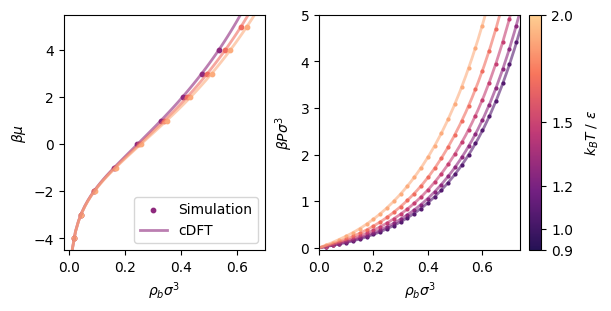

In [32]:
orig_cmap = plt.cm.magma
norm = mcolors.Normalize(vmin=min(T), vmax=max(T)) # Required for the colourbar
colors = orig_cmap(np.linspace(0.15, 0.9, len(T))) # Restrict colour range of the colourmap
cmap = mcolors.LinearSegmentedColormap.from_list("mycmap", colors)
plot_colour = cmap(np.linspace(0.15, 0.9, len(T)))

fig, axs = plt.subplots(ncols=2, nrows=1, layout="compressed", figsize=(6,3))

for j in range(len(T)):
    axs[1].plot(rho_range, P_range[j], lw=2, color=plot_colour[j], alpha=0.6, label="cDFT" if j==0 else "")
    axs[1].scatter(density, press_wca[j], color=plot_colour[j], s=4, label="Simulation" if j==0 else "") # Results from MD simulations

axs[1].set_ylim(-0.05, 5)
axs[1].set_xlim(0, 0.74)

axs[1].set_xlabel("$ \\rho_b \\sigma^3$")
axs[1].set_ylabel("$\\beta P \\sigma^3$")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = fig.colorbar(sm, ax=axs, pad=0.02)
cbar.set_label('$ k_B T $ / $\\epsilon$', labelpad=8)
cbar.set_ticks(T)
cbar.set_ticklabels(T)

cut = [-11, -7, -6] # Density too high/Hasn't converged properly
axs[0].scatter(rho_wca_1[:cut[0]], mu_wca_1[:cut[0]], label="Simulation", color=plot_colour[1], s=10)
axs[0].scatter(rho_wca_15[:cut[1]], mu_wca_15[:cut[1]], color=plot_colour[3], s=10)
axs[0].scatter(rho_wca_2[:cut[2]], mu_wca_2[:cut[2]], color=plot_colour[4], s=10)

for i in range(len(T)):
    if i== 1 or i==3 or i==4:
        axs[0].plot(rho, mu[i], label="cDFT" if i==1 else "", alpha=0.6, linewidth=2, color=plot_colour[i])

axs[0].set_xlabel("$ \\rho_{b} \\sigma^3 $")
axs[0].set_ylabel("$ \\beta \\mu $")
axs[0].set_xlim(-0.02, 0.7)
axs[0].set_ylim(-4.5, 5.5)

axs[0].legend(frameon=True, loc="lower right")

#plt.savefig("../wca_eos.png", bbox_inches="tight",dpi=600, pad_inches=0.01)
plt.show()


## LJ Equations of State

#### Calculate Pressure

In [33]:
kB  = 1
T = [0.9, 1.0, 1.2, 1.5, 2.0]

model_path = "../../models/WCA.keras"
model = keras.models.load_model(model_path)

width = 0.005
A = 100 # Lateral system area
V = 1000 # Total system volume

rho_range = np.linspace(0.001, 1.1, 50)
Fexc_range_lr = np.empty_like(rho_range)
derivPhi_lr = np.empty_like(rho_range)
z_range = np.ones((2000))
P_LR = np.empty((len(T), len(rho_range)))

for j in range(len(T)):
    for i in range(len(rho_range)):
    
        rho_array = z_range * rho_range[i]

        Fex, c1 = Fexc_LR(model, rho_array, T[j], dx=width, rc=2.5)

        Fexc_range_lr[i] = kB * T[j] * Fex
        derivPhi_lr[i] = -np.mean(c1) * kB * T[j]

    P_LR[j] = (derivPhi_lr + kB*T[j]) * rho_range - Fexc_range_lr*A/V

/tmp/ipykernel_21680/3069048240.py:79: RuntimeWarning: divide by zero encountered in log
  mu_R = np.log(alpha*rho) - c1_sr
/home/katie/Github/finalised-scripts/cdft/scripts/../LJEOS.py:121: RuntimeWarning: divide by zero encountered in log
  mu = s.chemical_potential(Contributions.Residual) / (si.RGAS* t*epsilon_k) + np.log(rho) # beta mu


In [ ]:
"""
np.savetxt("../data/lj_pressure_eos.dat", 
           np.c_[rho_range, P_LR.T], 
           delimiter=" ", 
           header="rho_b " + " ".join([f"P_T{T[i]:.3f}" for i in range(P_LR.shape[0])]), 
           comments="", 
           fmt=['%.5f'] + ['%.20f'] * P_LR.shape[0])
"""

#### Calculate Chemical Potential

In [36]:
input_bins = 2000
rho = np.linspace(0.00001, 1.1, num=100)
mu_lj = np.empty((len(T), len(rho)))

for j in range(len(T)):
    for i in range(len(rho)):
        rho_array = np.linspace(rho[i], rho[i], num=input_bins)
        rho_log = np.log(rho_array)

        c1 = c1_pred_lr(model, rho_array, T[j])
        mu_lj[j, i] = np.mean(rho_log - c1)

In [37]:
"""
np.savetxt("../data/lj_mu_eos.dat", 
           np.c_[rho, mu_lj.T], 
           delimiter=" ", 
           header="rho_b " + " ".join([f"mu_T{T[i]:.3f}" for i in range(mu_lj.shape[0])]), 
           comments="", 
           fmt=['%.5f'] + ['%.20f'] * mu_lj.shape[0])
"""

#### Load Data and Plot Graphs

In [39]:
pressure_lj_df = pd.read_csv("../data/results/eos/lj_pressure_eos.dat", sep=" ", header=None, skiprows=1)
mu_lj_df = pd.read_csv("../data/results/eos/lj_mu_eos.dat", sep=" ", header=None, skiprows=1)

P_LR = np.array([pressure_lj_df[i+1] for i in range(len(T))])
mu_lj = np.array([mu_lj_df[i+1] for i in range(len(T))])

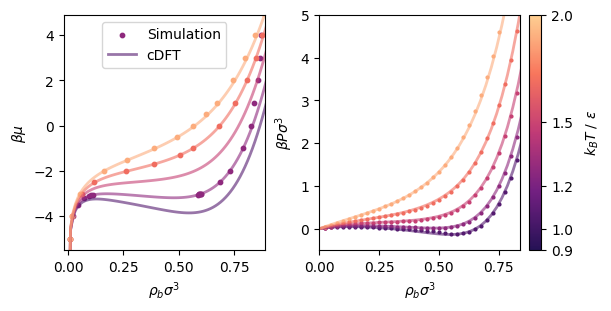

In [40]:

orig_cmap = plt.cm.magma
norm = mcolors.Normalize(vmin=min(T), vmax=max(T)) # Required for the colourbar
colors = orig_cmap(np.linspace(0.15, 0.9, len(T))) # Restrict colour range of the colourmap
cmap = mcolors.LinearSegmentedColormap.from_list("mycmap", colors)
plot_colour = cmap(np.linspace(0.15, 0.9, len(T)))

fig, axs = plt.subplots(ncols=2, nrows=1, layout="compressed", figsize=(6,3))

for j in range(len(T)):
    axs[1].plot(rho_range, P_LR[j], lw=2, color=plot_colour[j], alpha=0.6, label="cDFT" if j==0 else "")
    axs[1].scatter(density, press_lj[j], color=plot_colour[j], s=4, label="Simulation" if j==0 else "") # Results from MD simulations

axs[1].set_ylim(-0.5, 5)
axs[1].set_xlim(0, 0.84)

axs[1].set_xlabel("$ \\rho_b \\sigma^3$")
axs[1].set_ylabel("$\\beta P \\sigma^3$")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = fig.colorbar(sm, ax=axs, pad=0.02)
cbar.set_label('$ k_B T $ / $\\epsilon$', labelpad=8)
cbar.set_ticks(T)
cbar.set_ticklabels(T)

cut = [-11, -7, -6] # Density too high/Hasn't converged properly
axs[0].scatter(rho_lj_1[:cut[0]], mu_lj_1[:cut[0]], label="Simulation", color=plot_colour[1], s=10)
axs[0].scatter(rho_lj_15[:cut[1]], mu_lj_15[:cut[1]], color=plot_colour[3], s=10)
axs[0].scatter(rho_lj_2[:cut[2]], mu_lj_2[:cut[2]], color=plot_colour[4], s=10)

for i in range(len(T)):
    axs[0].plot(rho, mu_lj[i], label="cDFT" if i==0 else "", alpha=0.6, linewidth=2, color=plot_colour[i])

axs[0].set_xlabel("$ \\rho_{b} \\sigma^3 $")
axs[0].set_ylabel("$ \\beta \\mu $")
axs[0].set_xlim(-0.02, 0.89)
axs[0].set_ylim(-5.5, 4.9)

axs[0].legend(frameon=True, loc="upper center")

#plt.savefig("../lj_eos.png", bbox_inches="tight",dpi=600, pad_inches=0.01)
plt.show()
